# Assignment 2 - Training Results Analysis

## Logs

### Overview

In [2]:
import json
import os
from pathlib import Path

DATA_DIR = Path('data')
LOGS_DIR = DATA_DIR / 'logs'
MODELS_DIR = DATA_DIR / 'models'

# Experiment metadata
EXPERIMENT_META = {
    '1': {'label': 'GRU enc-only (no dropout)',  'arch': 'GRU', 'dropout': 0.0, 'encoder_only': True,  'with_attn': None,  'color': 'tab:blue'},
    '2': {'label': 'GRU enc-only (dropout)',      'arch': 'GRU', 'dropout': 0.3, 'encoder_only': True,  'with_attn': None,  'color': 'tab:orange'},
    '3': {'label': 'GRU enc-dec (no attn)',       'arch': 'GRU', 'dropout': 0.3, 'encoder_only': False, 'with_attn': False, 'color': 'tab:green'},
    '4': {'label': 'GRU enc-dec (attn)',          'arch': 'GRU', 'dropout': 0.3, 'encoder_only': False, 'with_attn': True,  'color': 'tab:red'},
    '5': {'label': 'Transformer 2L prenorm',      'arch': 'Transformer', 'num_heads': 4, 'num_layers': 2, 'block': 'prenorm',  'dropout': 0.3, 'color': 'tab:purple'},
    '6': {'label': 'Transformer 4L prenorm',      'arch': 'Transformer', 'num_heads': 4, 'num_layers': 4, 'block': 'prenorm',  'dropout': 0.3, 'color': 'tab:brown'},
    '7': {'label': 'Transformer 2L postnorm',     'arch': 'Transformer', 'num_heads': 4, 'num_layers': 2, 'block': 'postnorm', 'dropout': 0.3, 'color': 'tab:pink'},
    '8': {'label': 'Pretrained BERT',             'arch': 'BERT', 'color': 'tab:gray'},
}

def exp_label(name):
    meta = EXPERIMENT_META.get(name)
    return meta['label'] if meta else f'Exp {name}'

def exp_color(name):
    meta = EXPERIMENT_META.get(name)
    return meta['color'] if meta else None

# Load all experiment logs
experiments = {}
for exp_dir in sorted(LOGS_DIR.iterdir()):
    if exp_dir.is_dir():
        log_file = exp_dir / 'args.json'
        if log_file.exists():
            with open(log_file) as f:
                experiments[exp_dir.name] = json.load(f)

print(f"Found {len(experiments)} experiments: {list(experiments.keys())}")
print()

# Overview of each experiment
for name, data in experiments.items():
    print(f"--- {exp_label(name)} (exp {name}) ---")
    print(f"  Parameters: {data['parameters']:,}")
    print(f"  Epochs: {len(data.get('train_loss_epoch', []))}")
    print(f"  Log steps: {len(data.get('train_loss_logfreq', []))}")
    print(f"  Total train time: {data['train_time_accum'][-1]:.1f}s")
    print(f"  Final train loss (epoch): {data['train_loss_epoch'][-1]:.4f}")
    print(f"  Final eval loss (epoch):  {data['eval_loss_epoch'][-1]:.4f}")
    print(f"  Final eval accuracy:      {data['eval_acc_epoch'][-1]:.4f}")
    print()

Found 8 experiments: ['1', '2', '3', '4', '5', '6', '7', '8']

--- GRU enc-only (no dropout) (exp 1) ---
  Parameters: 8,603,650
  Epochs: 5
  Log steps: 235
  Total train time: 3469.7s
  Final train loss (epoch): 0.1588
  Final eval loss (epoch):  0.1835
  Final eval accuracy:      0.9440

--- GRU enc-only (dropout) (exp 2) ---
  Parameters: 8,603,650
  Epochs: 5
  Log steps: 235
  Total train time: 3480.7s
  Final train loss (epoch): 0.1985
  Final eval loss (epoch):  0.6797
  Final eval accuracy:      0.8710

--- GRU enc-dec (no attn) (exp 3) ---
  Parameters: 8,998,402
  Epochs: 5
  Log steps: 235
  Total train time: 4531.8s
  Final train loss (epoch): 0.1896
  Final eval loss (epoch):  0.7561
  Final eval accuracy:      0.8650

--- GRU enc-dec (attn) (exp 4) ---
  Parameters: 9,195,522
  Epochs: 5
  Log steps: 235
  Total train time: 4806.3s
  Final train loss (epoch): 0.1968
  Final eval loss (epoch):  0.6203
  Final eval accuracy:      0.8720

--- Transformer 2L prenorm (exp 5) 

In [3]:
# Show all available keys in the log data
sample = next(iter(experiments.values()))
print("Available metrics in each log file:")
for key, value in sample.items():
    if isinstance(value, list):
        print(f"  {key}: list of {len(value)} values (e.g., {value[0]:.4f} ... {value[-1]:.4f})")
    else:
        print(f"  {key}: {value}")

Available metrics in each log file:
  parameters: 8603650
  train_time_accum: list of 236 values (e.g., 0.0000 ... 3469.7063)
  train_loss_logfreq: list of 235 values (e.g., 0.6882 ... 0.1424)
  train_loss_epoch: list of 5 values (e.g., 0.3551 ... 0.1588)
  train_time_epoch: list of 5 values (e.g., 753.5608 ... 737.6934)
  eval_time_accum: list of 236 values (e.g., 0.0000 ... 193.3571)
  eval_acc_logfreq: list of 235 values (e.g., 0.5720 ... 0.9440)
  eval_tp_rate_logfreq: list of 235 values (e.g., 0.3876 ... 0.9358)
  eval_fp_rate_logfreq: list of 235 values (e.g., 0.2664 ... 0.0488)
  eval_tn_rate_logfreq: list of 235 values (e.g., 0.7336 ... 0.9512)
  eval_fn_rate_logfreq: list of 235 values (e.g., 0.6124 ... 0.0642)
  eval_f1_score_logfreq: list of 235 values (e.g., 0.4582 ... 0.9398)
  eval_loss_logfreq: list of 235 values (e.g., 0.6761 ... 0.1835)
  eval_loss_epoch: list of 5 values (e.g., 0.2510 ... 0.1835)
  eval_time_epoch: list of 5 values (e.g., 0.7049 ... 1.1569)
  eval_acc

In [4]:
# Check what model files are available
print("Model files:")
for model_dir in sorted(MODELS_DIR.iterdir()):
    if model_dir.is_dir():
        for f in model_dir.iterdir():
            size_mb = f.stat().st_size / (1024 * 1024)
            print(f"  {model_dir.name}/{f.name}: {size_mb:.1f} MB")

Model files:
  1/model_1.pt: 32.8 MB
  2/model_2.pt: 32.8 MB
  3/model_3.pt: 34.3 MB
  4/model_4.pt: 35.1 MB
  5/model_5.pt: 33.1 MB
  6/model_6.pt: 36.1 MB
  7/model_7.pt: 33.1 MB


### Full Experiment Comparison

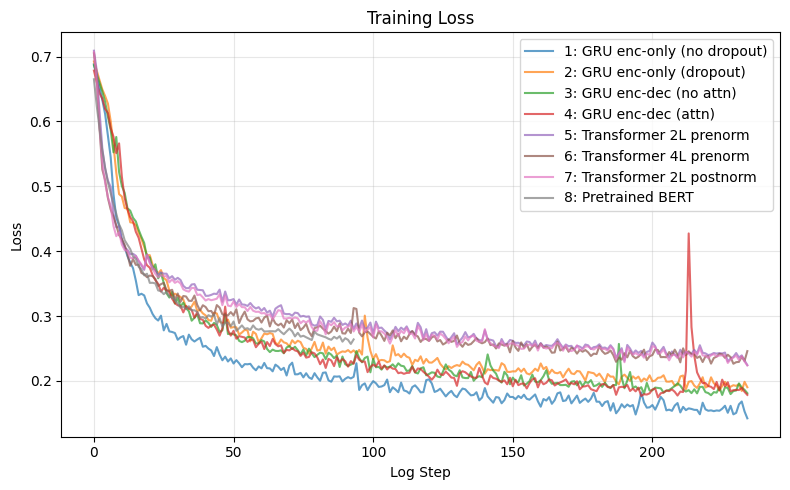

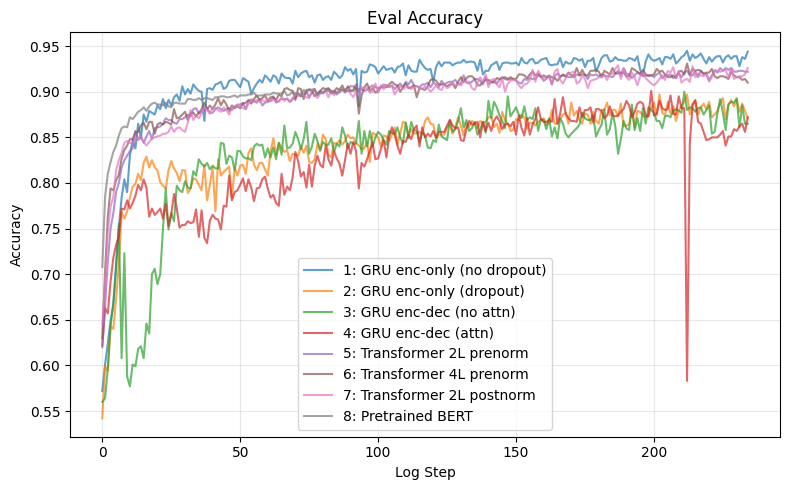

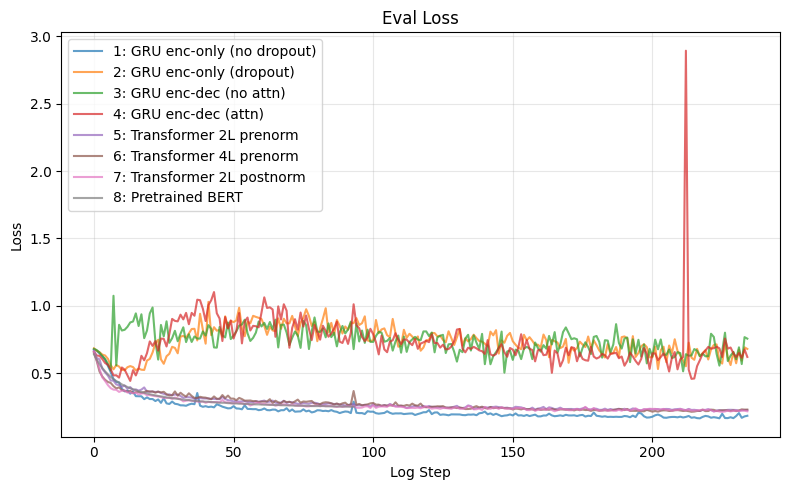

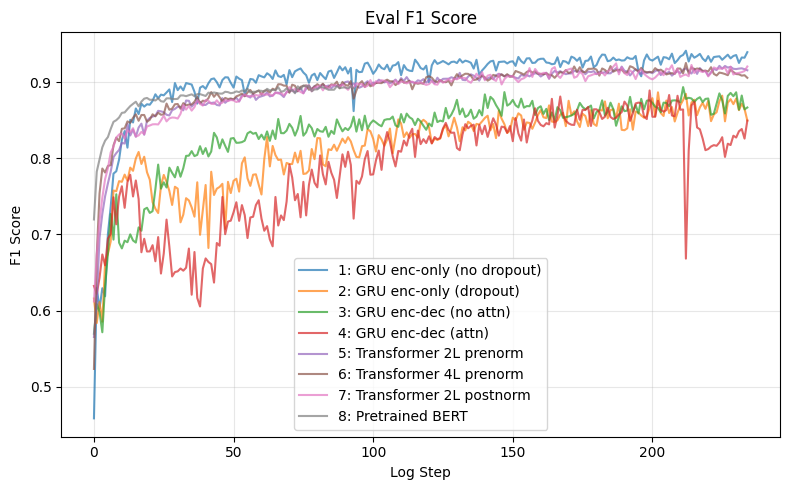

In [5]:
import matplotlib.pyplot as plt
import os

FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

plots = [
    ('train_loss_logfreq', 'Training Loss', 'Log Step', 'Loss', 'train_loss'),
    ('eval_acc_logfreq', 'Eval Accuracy', 'Log Step', 'Accuracy', 'eval_accuracy'),
    ('eval_loss_logfreq', 'Eval Loss', 'Log Step', 'Loss', 'eval_loss'),
    ('eval_f1_score_logfreq', 'Eval F1 Score', 'Log Step', 'F1 Score', 'eval_f1'),
]

for key, title, xlabel, ylabel, filename in plots:
    fig, ax = plt.subplots(figsize=(8, 5))
    for name, data in experiments.items():
        ax.plot(data[key], label=f'{name}: {exp_label(name)}', color=exp_color(name), alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, f'{filename}.png'), dpi=150, bbox_inches='tight')
    plt.show()

# IMPORTANT: The downward spikes in training loss are due to a bug in the logging code.
# The calculation of avg loss is wrong for the last batch which has a smaller size.

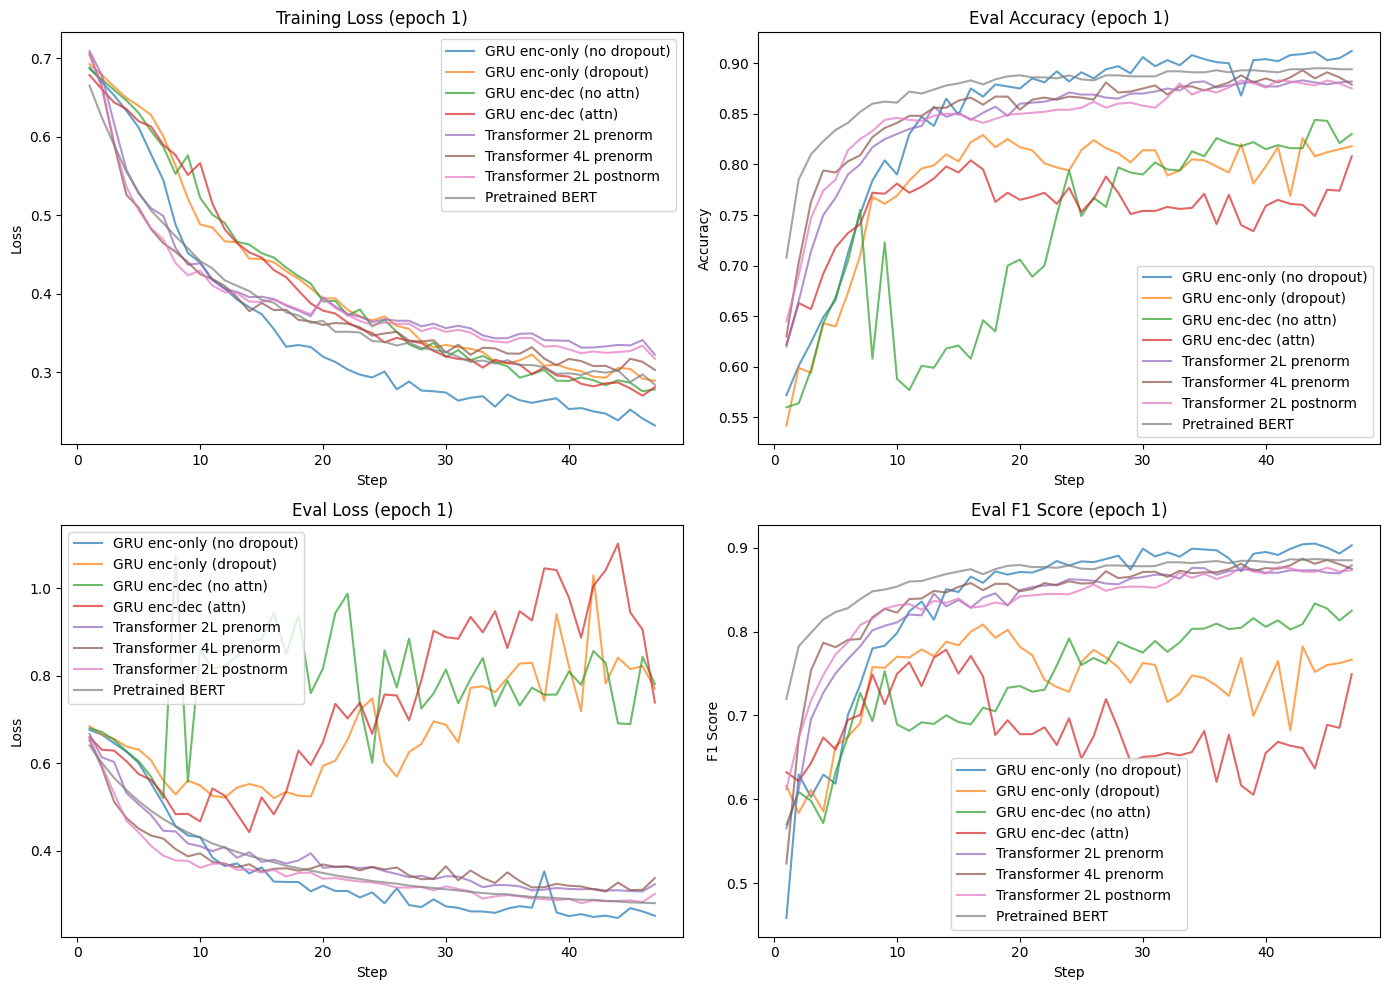

In [6]:
# First epoch only (zoomed in)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ('train_loss_logfreq', 'Training Loss (epoch 1)', 'Loss'),
    ('eval_acc_logfreq', 'Eval Accuracy (epoch 1)', 'Accuracy'),
    ('eval_loss_logfreq', 'Eval Loss (epoch 1)', 'Loss'),
    ('eval_f1_score_logfreq', 'Eval F1 Score (epoch 1)', 'F1 Score'),
]

for ax, (key, title, ylabel) in zip(axes.flatten(), metrics):
    for name, data in experiments.items():
        n_epochs = len(data['train_loss_epoch'])
        n_steps = len(data[key])
        steps_per_epoch = n_steps // n_epochs
        ax.plot(range(1, steps_per_epoch + 1), data[key][:steps_per_epoch],
                label=exp_label(name), color=exp_color(name), alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Step')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()

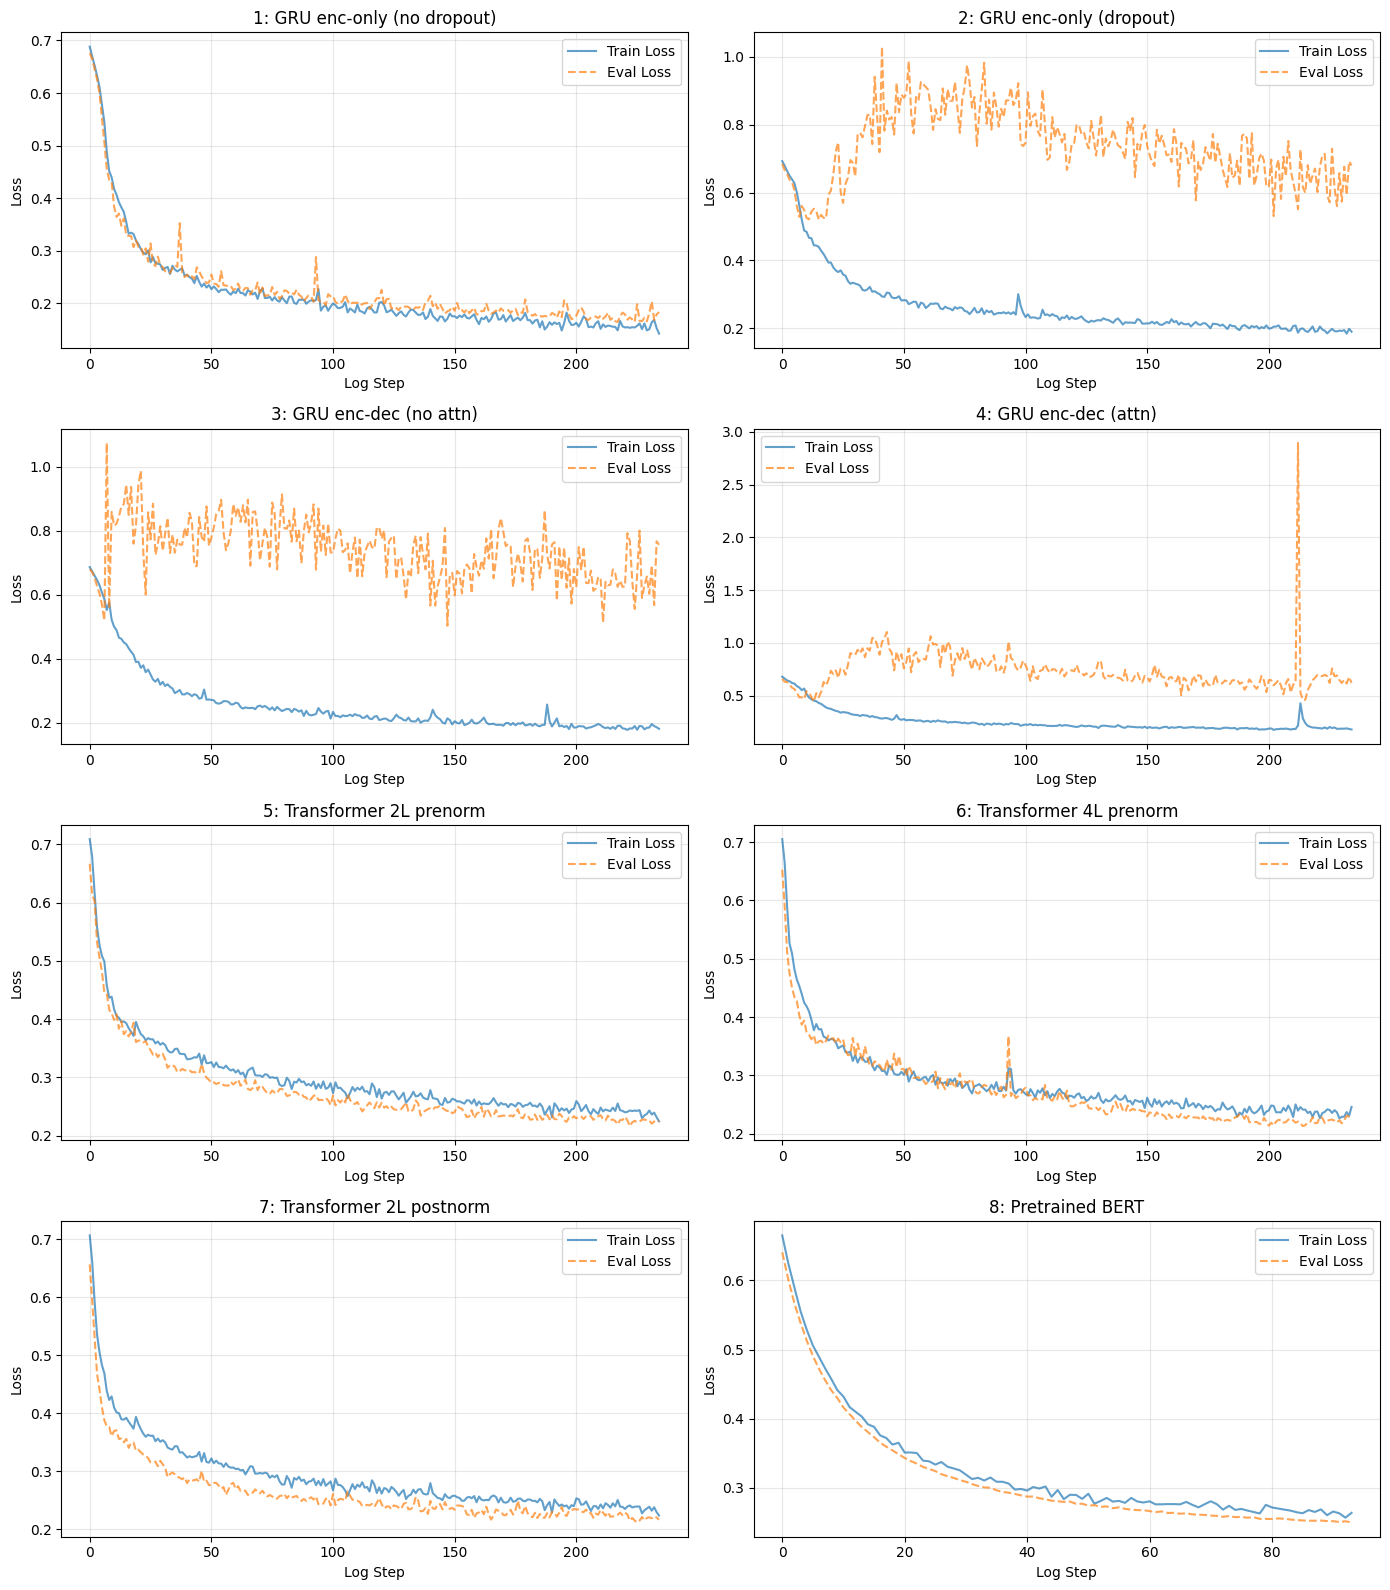

In [7]:
# create one plot for each experiment. each plot should show training loss and eval loss
exp_items = list(experiments.items())
n_exps = len(exp_items)
n_rows = (n_exps + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for idx, (name, data) in enumerate(exp_items):
    ax = axes[idx]
    ax.plot(data['train_loss_logfreq'], label='Train Loss', color='tab:blue', alpha=0.7)
    ax.plot(data['eval_loss_logfreq'], label='Eval Loss', color='tab:orange', alpha=0.7, linestyle='--')
    ax.set_title(f'{name}: {exp_label(name)}')
    ax.set_xlabel('Log Step')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused axes
for idx in range(n_exps, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'train_eval_loss_all.png'), dpi=150, bbox_inches='tight')
plt.show()

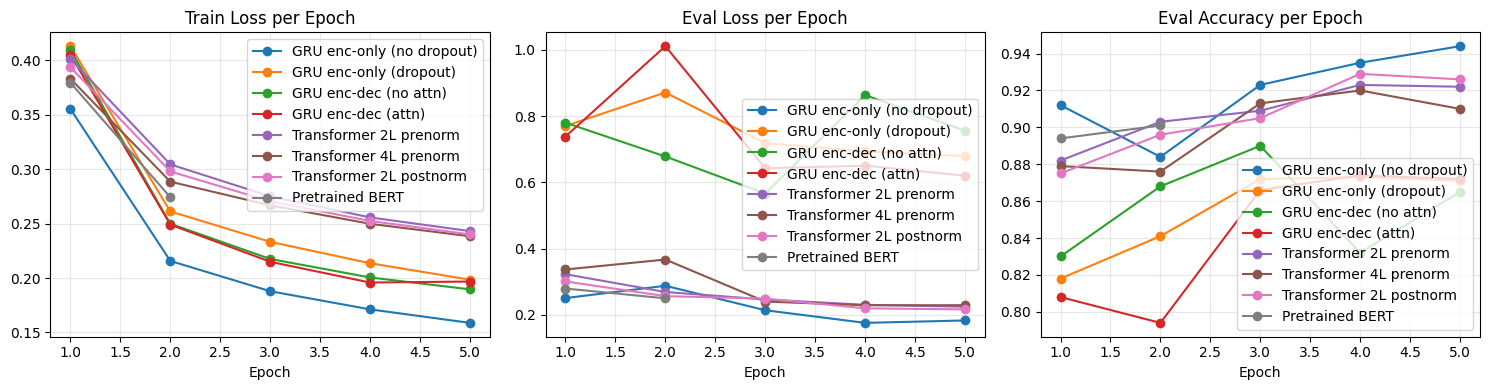

In [8]:
# Epoch-level summary comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for name, data in experiments.items():
    label = exp_label(name)
    color = exp_color(name)
    epochs = range(1, len(data['train_loss_epoch']) + 1)
    axes[0].plot(epochs, data['train_loss_epoch'], marker='o', label=label, color=color)
    axes[1].plot(epochs, data['eval_loss_epoch'], marker='o', label=label, color=color)
    axes[2].plot(epochs, data['eval_acc_epoch'], marker='o', label=label, color=color)

axes[0].set_title('Train Loss per Epoch')
axes[1].set_title('Eval Loss per Epoch')
axes[2].set_title('Eval Accuracy per Epoch')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Confusion matrix rates comparison (final values)
import pandas as pd

rows = []
for name, data in experiments.items():
    rows.append({
        'Experiment': exp_label(name),
        'Parameters': f"{data['parameters']:,}",
        'Final Accuracy': f"{data['eval_acc_epoch'][-1]:.4f}",
        'Final F1': f"{data['eval_f1_score_logfreq'][-1]:.4f}",
        'TP Rate': f"{data['eval_tp_rate_logfreq'][-1]:.4f}",
        'FP Rate': f"{data['eval_fp_rate_logfreq'][-1]:.4f}",
        'TN Rate': f"{data['eval_tn_rate_logfreq'][-1]:.4f}",
        'FN Rate': f"{data['eval_fn_rate_logfreq'][-1]:.4f}",
        'Train Time (s)': f"{data['train_time_accum'][-1]:.0f}",
    })

df = pd.DataFrame(rows)
df

,Experiment,Parameters,Final Accuracy,Final F1,TP Rate,FP Rate,TN Rate,FN Rate,Train Time (s)
0,GRU enc-only (no dropout),"8,603,650",0.9440,0.9398,0.9358,0.0488,0.9512,0.0642,3470
1,GRU enc-only (dropout),"8,603,650",0.8710,0.8498,0.7816,0.0507,0.9493,0.2184,3481
2,GRU enc-dec (no attn),"8,998,402",0.8650,0.8670,0.9422,0.2026,0.7974,0.0578,4532
3,GRU enc-dec (attn),"9,195,522",0.8720,0.8498,0.7752,0.0432,0.9568,0.2248,4806
4,Transformer 2L prenorm,"8,672,258",0.9220,0.9159,0.9101,0.0675,0.9325,0.0899,5549
5,Transformer 4L prenorm,"9,463,810",0.9100,0.9061,0.9293,0.1069,0.8931,0.0707,8520
6,Transformer 2L postnorm,"8,672,258",0.9260,0.9209,0.9229,0.0713,0.9287,0.0771,5221
7,Pretrained BERT,"1,538",0.9010,0.8923,0.8779,0.0788,0.9212,0.1221,16773


In [10]:
# Generate LaTeX table summarizing all experiments
import pandas as pd

rows = []
for name, data in sorted(experiments.items(), key=lambda x: int(x[0])):
    meta = EXPERIMENT_META.get(name, {})
    arch = meta.get('arch', '?')
    n_epochs = len(data['train_loss_epoch'])
    train_time = data['train_time_accum'][-1]
    eval_time = sum(data['eval_time_epoch']) / n_epochs  # avg eval time per epoch

    rows.append({
        'exp': name,
        'arch': arch,
        'desc': exp_label(name),
        'params': data['parameters'],
        'epochs': n_epochs,
        'train_loss': data['train_loss_epoch'][-1],
        'eval_loss': data['eval_loss_epoch'][-1],
        'eval_acc': data['eval_acc_epoch'][-1],
        'eval_f1': data['eval_f1_score_logfreq'][-1],
        'train_time': train_time,
        'eval_time': eval_time,
    })

df = pd.DataFrame(rows)

# Display in notebook for review
display_df = df.copy()
display_df.columns = ['Exp', 'Arch', 'Description', 'Params', 'Epochs',
                       'Train Loss', 'Val Loss', 'Val Acc', 'Val F1',
                       'Train Time (s)', 'Eval Time (s)']
display_df['Params'] = display_df['Params'].apply(lambda x: f"{x:,}")
display_df['Train Time (s)'] = display_df['Train Time (s)'].apply(lambda x: f"{x:.0f}")
display_df['Eval Time (s)'] = display_df['Eval Time (s)'].apply(lambda x: f"{x:.1f}")
for col in ['Train Loss', 'Val Loss', 'Val Acc', 'Val F1']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")

# Highlight best val acc
best_idx = df['eval_acc'].idxmax()
display_df = display_df.style.applymap(
    lambda v: 'font-weight: bold', subset=pd.IndexSlice[best_idx, :]
).set_caption("Experiment Results Summary (best validation accuracy in bold)")
display(display_df)

# Build LaTeX table
best_acc_idx = df['eval_acc'].idxmax()

latex_lines = []
latex_lines.append(r'\begin{table}[ht]')
latex_lines.append(r'\centering')
latex_lines.append(r'\caption{Summary of training and validation performance across all experiments. '
                   r'\textbf{Exp}: experiment number; '
                   r'\textbf{Arch}: model architecture; '
                   r'\textbf{Params}: number of trainable parameters; '
                   r'\textbf{Epochs}: number of training epochs; '
                   r'$\mathcal{L}_{\text{train}}$: final training loss (epoch-level); '
                   r'$\mathcal{L}_{\text{val}}$: final validation loss; '
                   r'\textbf{Val Acc}: final validation accuracy; '
                   r'\textbf{Val F1}: final validation F1 score; '
                   r'$T_{\text{train}}$: total training wall clock time (seconds); '
                   r'$T_{\text{eval}}$: average evaluation time per epoch (seconds). '
                   r'Best validation accuracy is shown in bold.}')
latex_lines.append(r'\label{tab:results}')
latex_lines.append(r'\resizebox{\textwidth}{!}{%')
latex_lines.append(r'\begin{tabular}{clcrccccccc}')
latex_lines.append(r'\toprule')
latex_lines.append(r'\textbf{Exp} & \textbf{Description} & \textbf{Arch} & \textbf{Params} & \textbf{Epochs} & $\mathcal{L}_{\text{train}}$ & $\mathcal{L}_{\text{val}}$ & \textbf{Val Acc} & \textbf{Val F1} & $T_{\text{train}}$ (s) & $T_{\text{eval}}$ (s) \\')
latex_lines.append(r'\midrule')

for i, row in df.iterrows():
    acc_str = f"{row['eval_acc']:.4f}"
    if i == best_acc_idx:
        acc_str = r'\textbf{' + acc_str + '}'

    line = (
        f"\\textbf{{{row['exp']}}} & "
        f"{row['desc']} & "
        f"{row['arch']} & "
        f"{row['params']:,} & "
        f"{row['epochs']} & "
        f"{row['train_loss']:.4f} & "
        f"{row['eval_loss']:.4f} & "
        f"{acc_str} & "
        f"{row['eval_f1']:.4f} & "
        f"{row['train_time']:.0f} & "
        f"{row['eval_time']:.1f} \\\\"
    )
    latex_lines.append(line)

latex_lines.append(r'\bottomrule')
latex_lines.append(r'\end{tabular}%')
latex_lines.append(r'}')
latex_lines.append(r'\end{table}')

latex_table = '\n'.join(latex_lines)
print(latex_table)

# Also save to file
with open(os.path.join(FIGURES_DIR, 'results_table.tex'), 'w') as f:
    f.write(latex_table)
print(f"\nSaved to {FIGURES_DIR}/results_table.tex")

/var/folders/29/r99kczp91990b27g8cgkfymh0000gn/T/ipykernel_54411/840286376.py:41: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display_df = display_df.style.applymap(


,Exp,Arch,Description,Params,Epochs,Train Loss,Val Loss,Val Acc,Val F1,Train Time (s),Eval Time (s)
0,1,GRU,GRU enc-only (no dropout),"8,603,650",5,0.1588,0.1835,0.9440,0.9398,3470,0.8
1,2,GRU,GRU enc-only (dropout),"8,603,650",5,0.1985,0.6797,0.8710,0.8498,3481,1.0
2,3,GRU,GRU enc-dec (no attn),"8,998,402",5,0.1896,0.7561,0.8650,0.8670,4532,1.0
3,4,GRU,GRU enc-dec (attn),"9,195,522",5,0.1968,0.6203,0.8720,0.8498,4806,0.9
4,5,Transformer,Transformer 2L prenorm,"8,672,258",5,0.2431,0.2249,0.9220,0.9159,5549,1.2
5,6,Transformer,Transformer 4L prenorm,"9,463,810",5,0.2383,0.2295,0.9100,0.9061,8520,1.6
6,7,Transformer,Transformer 2L postnorm,"8,672,258",5,0.2400,0.2168,0.9260,0.9209,5221,1.0
7,8,BERT,Pretrained BERT,"1,538",2,0.2741,0.2503,0.9010,0.8923,16773,14.7


\begin{table}[ht]
\centering
\caption{Summary of training and validation performance across all experiments. \textbf{Exp}: experiment number; \textbf{Arch}: model architecture; \textbf{Params}: number of trainable parameters; \textbf{Epochs}: number of training epochs; $\mathcal{L}_{\text{train}}$: final training loss (epoch-level); $\mathcal{L}_{\text{val}}$: final validation loss; \textbf{Val Acc}: final validation accuracy; \textbf{Val F1}: final validation F1 score; $T_{\text{train}}$: total training wall clock time (seconds); $T_{\text{eval}}$: average evaluation time per epoch (seconds). Best validation accuracy is shown in bold.}
\label{tab:results}
\resizebox{\textwidth}{!}{%
\begin{tabular}{clcrccccccc}
\toprule
\textbf{Exp} & \textbf{Description} & \textbf{Arch} & \textbf{Params} & \textbf{Epochs} & $\mathcal{L}_{\text{train}}$ & $\mathcal{L}_{\text{val}}$ & \textbf{Val Acc} & \textbf{Val F1} & $T_{\text{train}}$ (s) & $T_{\text{eval}}$ (s) \\
\midrule
\textbf{1} & GRU enc-on

### Individual Experiments

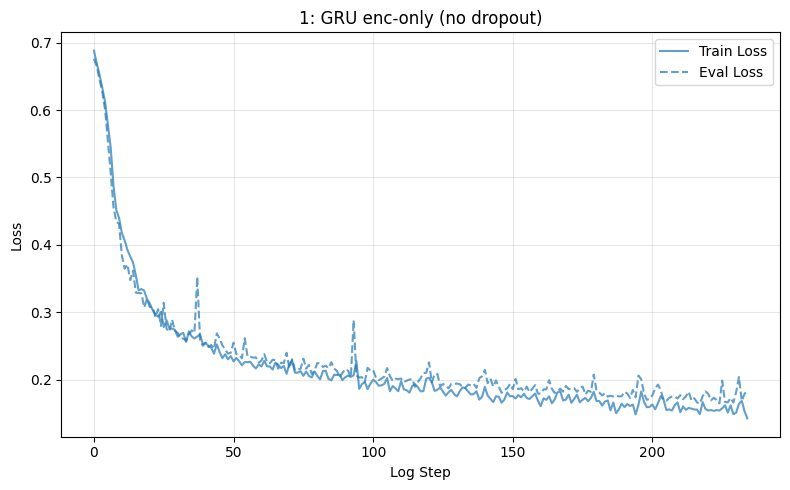

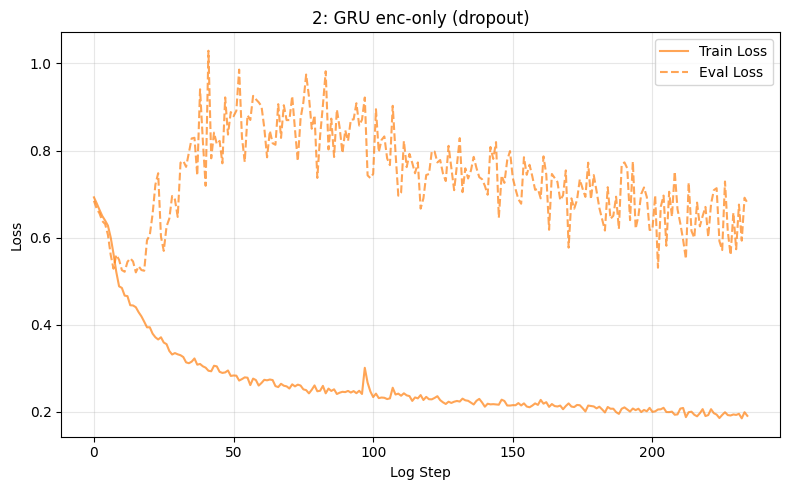

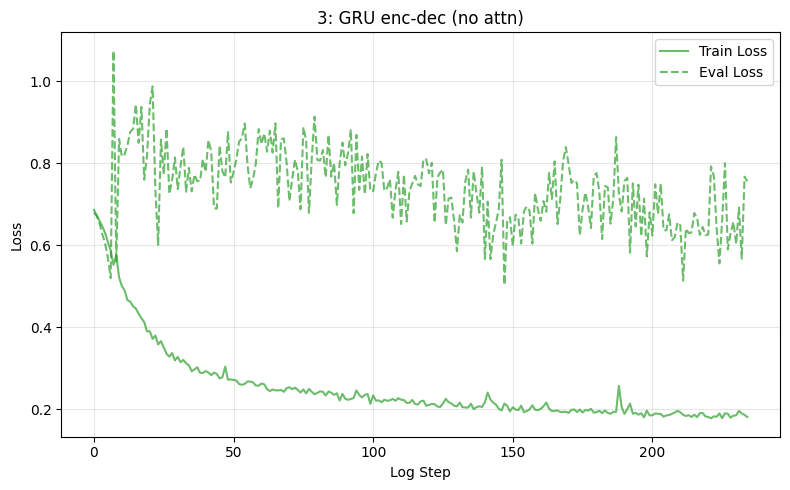

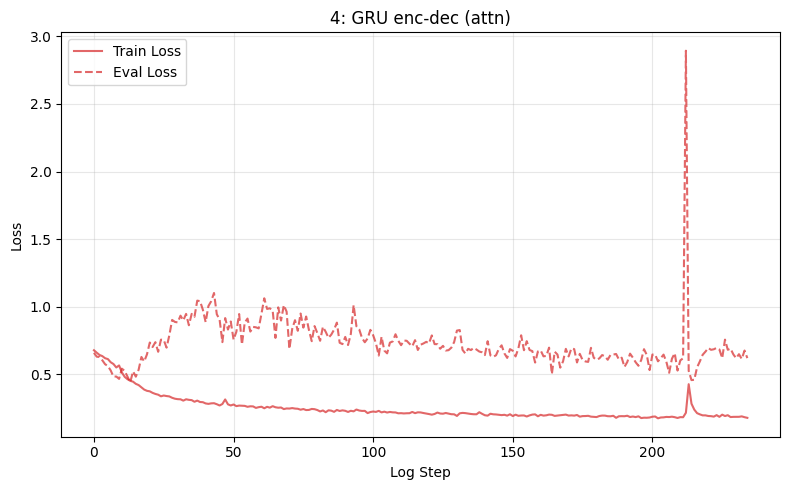

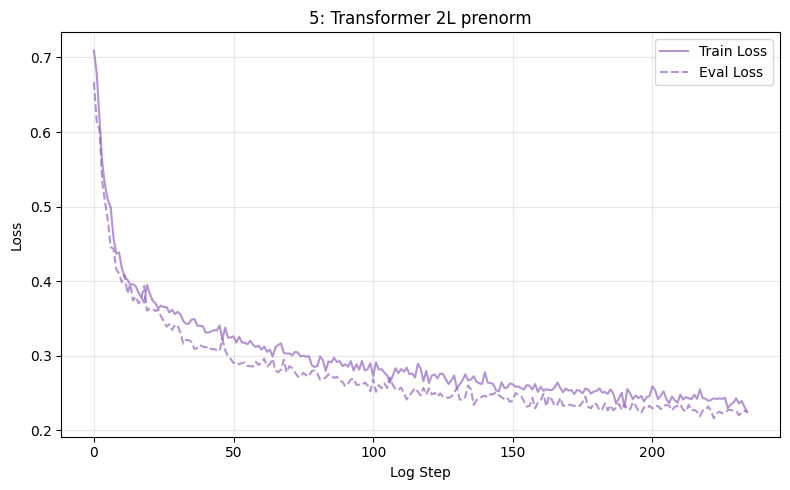

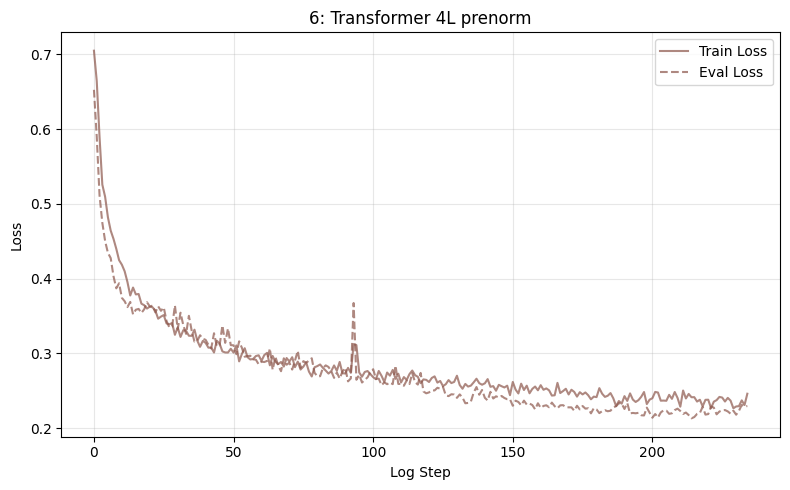

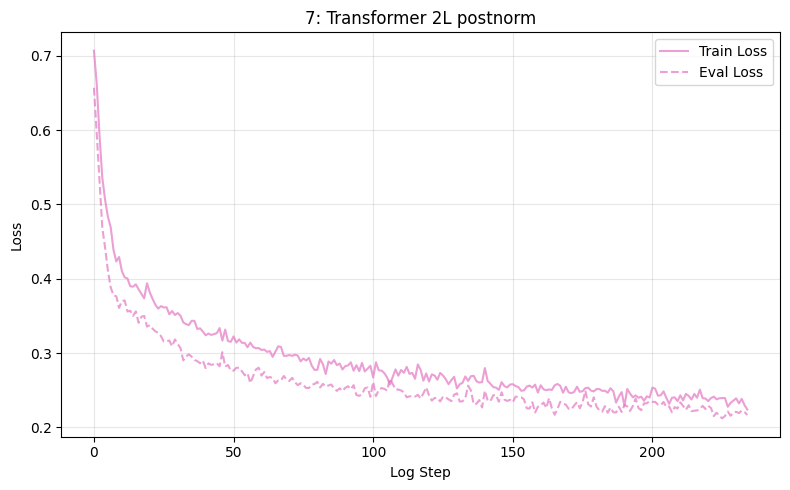

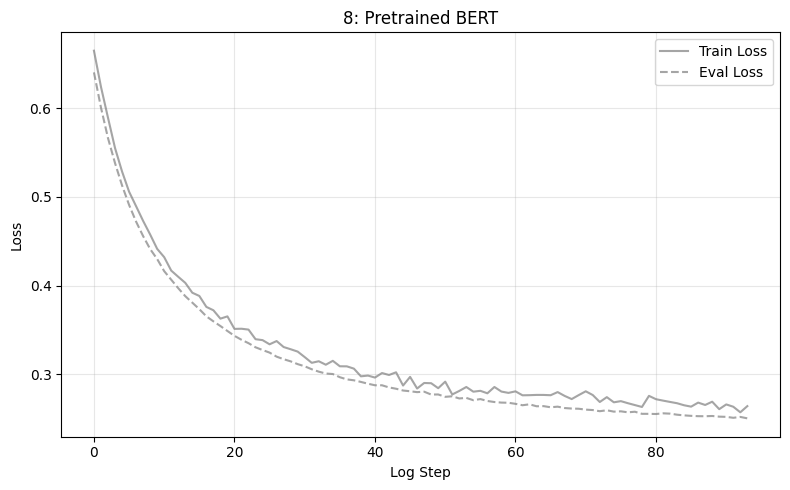

In [11]:
# Individual experiment plots: train loss vs eval loss
for name, data in experiments.items():
    color = exp_color(name)
    label = exp_label(name)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(data['train_loss_logfreq'], label='Train Loss', color=color, alpha=0.7)
    ax.plot(data['eval_loss_logfreq'], label='Eval Loss', color=color, alpha=0.7, linestyle='--')
    ax.set_title(f'{name}: {label}')
    ax.set_xlabel('Log Step')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, f'train_eval_loss_exp{name}.png'), dpi=150, bbox_inches='tight')
    plt.show()

## Model Weight Analysis

In [12]:
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load all model state dicts
state_dicts = {}
for model_dir in sorted(MODELS_DIR.iterdir()):
    if model_dir.is_dir():
        for f in sorted(model_dir.iterdir()):
            if f.suffix == '.pt':
                exp_id = model_dir.name
                state_dicts[exp_id] = torch.load(f, map_location=device, weights_only=True)

print(f"Loaded {len(state_dicts)} model checkpoints: {list(state_dicts.keys())}")

# Print layer names and shapes for each model
for exp_id, sd in state_dicts.items():
    print(f"\n--- {exp_label(exp_id)} (exp {exp_id}) ---")
    for key, param in sd.items():
        print(f"  {key}: {list(param.shape)}")

Loaded 7 model checkpoints: ['1', '2', '3', '4', '5', '6', '7']

--- GRU enc-only (no dropout) (exp 1) ---
  back_bone.encoder.embedding.weight: [30522, 256]
  back_bone.encoder.rnn.weight_ih_l0: [768, 256]
  back_bone.encoder.rnn.weight_hh_l0: [768, 256]
  back_bone.encoder.rnn.bias_ih_l0: [768]
  back_bone.encoder.rnn.bias_hh_l0: [768]
  back_bone.encoder.rnn.weight_ih_l0_reverse: [768, 256]
  back_bone.encoder.rnn.weight_hh_l0_reverse: [768, 256]
  back_bone.encoder.rnn.bias_ih_l0_reverse: [768]
  back_bone.encoder.rnn.bias_hh_l0_reverse: [768]
  classifier.weight: [2, 256]
  classifier.bias: [2]

--- GRU enc-only (dropout) (exp 2) ---
  back_bone.encoder.embedding.weight: [30522, 256]
  back_bone.encoder.rnn.weight_ih_l0: [768, 256]
  back_bone.encoder.rnn.weight_hh_l0: [768, 256]
  back_bone.encoder.rnn.bias_ih_l0: [768]
  back_bone.encoder.rnn.bias_hh_l0: [768]
  back_bone.encoder.rnn.weight_ih_l0_reverse: [768, 256]
  back_bone.encoder.rnn.weight_hh_l0_reverse: [768, 256]
  back

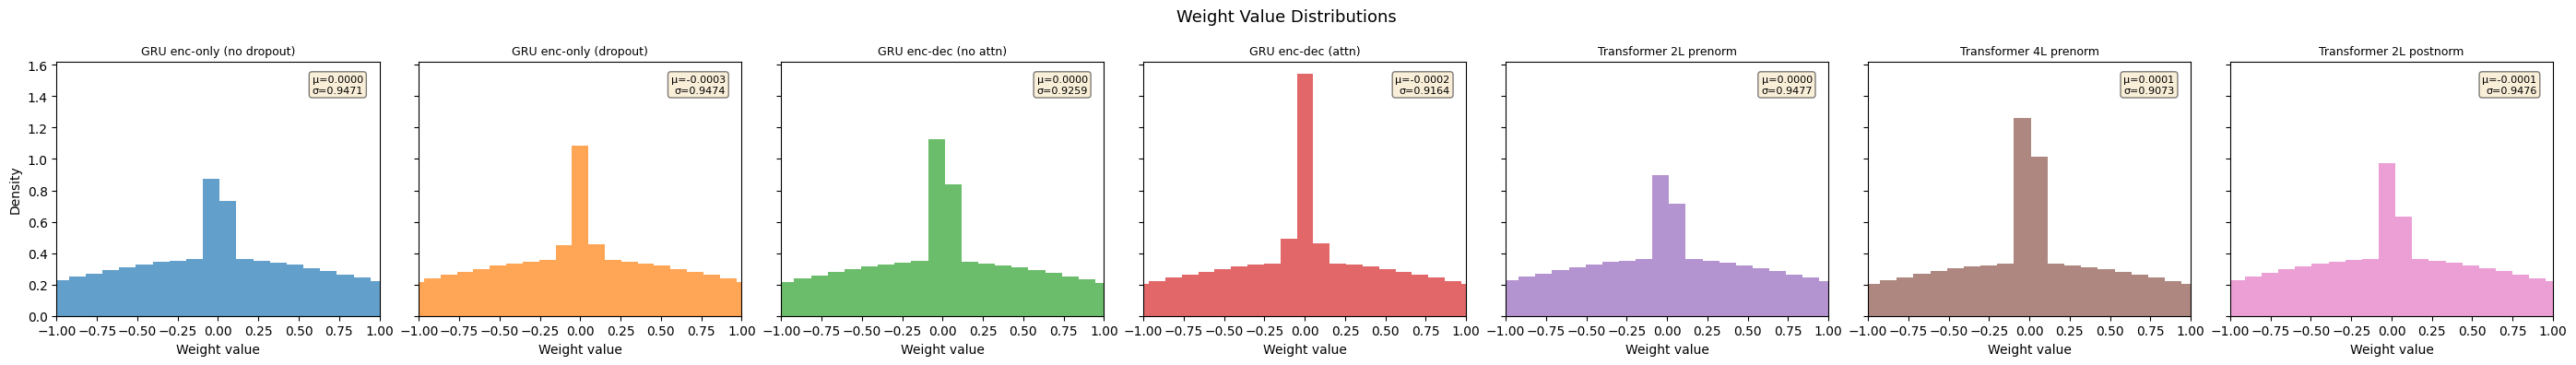

In [13]:
# 1. Weight distributions — histogram of weight magnitudes per experiment
fig, axes = plt.subplots(1, len(state_dicts), figsize=(4 * len(state_dicts), 4), sharey=True)
if len(state_dicts) == 1:
    axes = [axes]

for ax, (exp_id, sd) in zip(axes, state_dicts.items()):
    all_weights = torch.cat([p.flatten().float().cpu() for p in sd.values()])
    ax.hist(all_weights.numpy(), bins=100, alpha=0.7, color=exp_color(exp_id), density=True)
    ax.set_title(exp_label(exp_id), fontsize=9)
    ax.set_xlabel('Weight value')
    ax.set_xlim(-1, 1)
    stats = f"μ={all_weights.mean():.4f}\nσ={all_weights.std():.4f}"
    ax.text(0.95, 0.95, stats, transform=ax.transAxes, va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0].set_ylabel('Density')
fig.suptitle('Weight Value Distributions', fontsize=13)
plt.tight_layout()
plt.show()

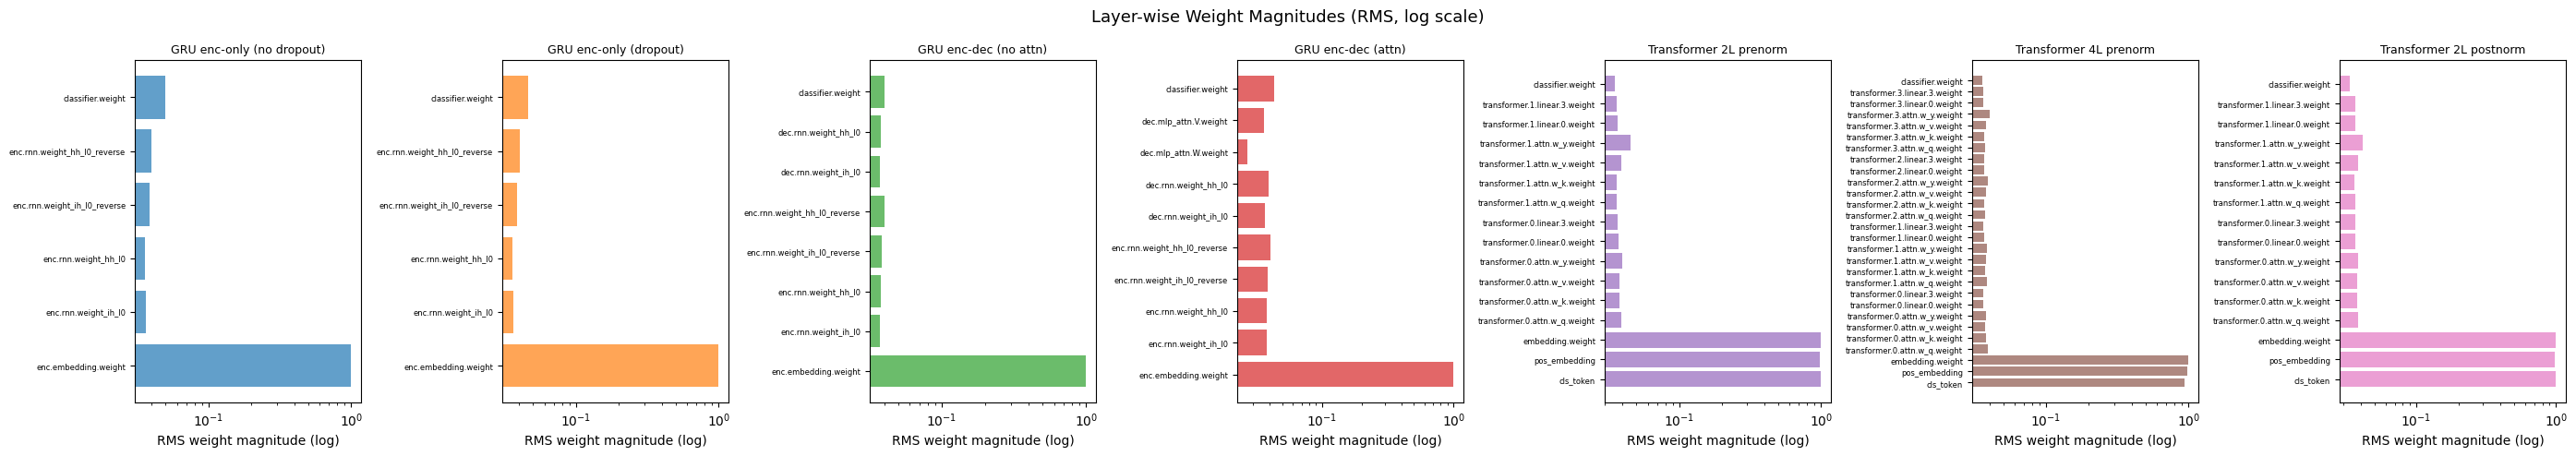

In [14]:
# 2. Layer-wise weight norms — compare magnitude across layers per experiment
fig, axes = plt.subplots(1, len(state_dicts), figsize=(4 * len(state_dicts), 5))
if len(state_dicts) == 1:
    axes = [axes]

for ax, (exp_id, sd) in zip(axes, state_dicts.items()):
    layer_names = []
    layer_norms = []
    for key, param in sd.items():
        if param.ndim >= 2:
            short_key = key.replace('back_bone.', '').replace('encoder.', 'enc.').replace('decoder.', 'dec.')
            layer_names.append(short_key)
            layer_norms.append(param.float().cpu().norm().item() / (param.numel() ** 0.5))

    y_pos = range(len(layer_names))
    ax.barh(y_pos, layer_norms, color=exp_color(exp_id), alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(layer_names, fontsize=6)
    ax.set_title(exp_label(exp_id), fontsize=9)
    ax.set_xlabel('RMS weight magnitude (log)')
    ax.set_xscale('log')

fig.suptitle('Layer-wise Weight Magnitudes (RMS, log scale)', fontsize=13)
plt.tight_layout()
plt.show()

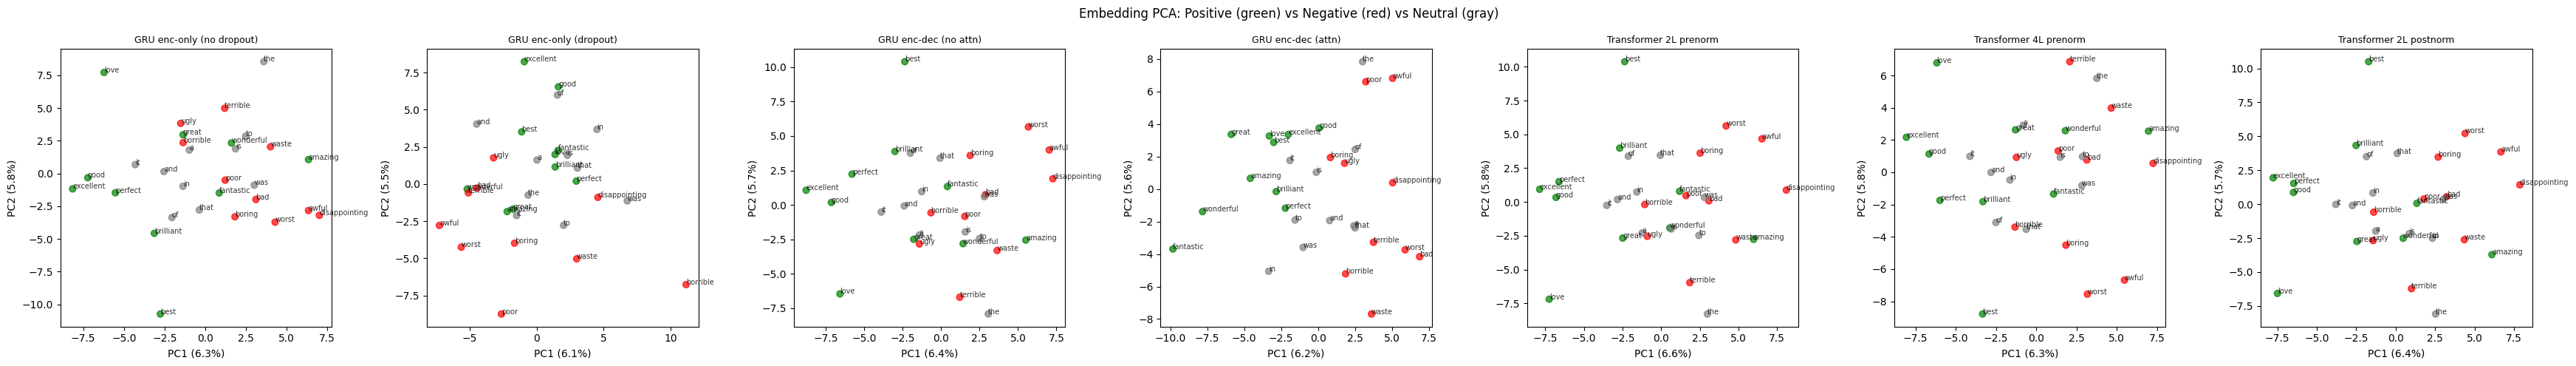

In [15]:
# 3. Embedding analysis — PCA of learned word embeddings
# All GRU models share the same embedding key; compare how training shaped them
from sklearn.decomposition import PCA
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Sentiment-relevant words to highlight
highlight_words = [
    'good', 'great', 'excellent', 'amazing', 'wonderful', 'fantastic', 'love', 'best', 'perfect', 'brilliant',
    'bad', 'terrible', 'awful', 'horrible', 'worst', 'boring', 'waste', 'poor', 'disappointing', 'ugly',
    'the', 'a', 'is', 'of', 'and', 'to', 'in', 'it', 'that', 'was',  # neutral/stopwords
]
highlight_ids = [tokenizer.convert_tokens_to_ids(w) for w in highlight_words]

fig, axes = plt.subplots(1, len(state_dicts), figsize=(5 * len(state_dicts), 5))
if len(state_dicts) == 1:
    axes = [axes]

for ax, (exp_id, sd) in zip(axes, state_dicts.items()):
    # Find embedding weight
    emb_key = [k for k in sd.keys() if 'embedding.weight' in k][0]
    embeddings = sd[emb_key].float().cpu().numpy()

    # PCA on the highlighted words
    highlight_embs = embeddings[highlight_ids]
    pca = PCA(n_components=2)
    coords = pca.fit_transform(highlight_embs)

    # Color: green=positive, red=negative, gray=neutral
    n_pos, n_neg = 10, 10
    colors = ['green'] * n_pos + ['red'] * n_neg + ['gray'] * (len(highlight_words) - n_pos - n_neg)

    ax.scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.7, s=40)
    for i, word in enumerate(highlight_words):
        ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.8)

    ax.set_title(exp_label(exp_id), fontsize=9)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

fig.suptitle('Embedding PCA: Positive (green) vs Negative (red) vs Neutral (gray)', fontsize=12)
plt.tight_layout()
plt.show()

/Users/travisholt/github/trvslhlt/ift_6135_representation_learning/.venv/lib/python3.11/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Number of captured weights: 1
Shape of each: torch.Size([1, 256, 1])


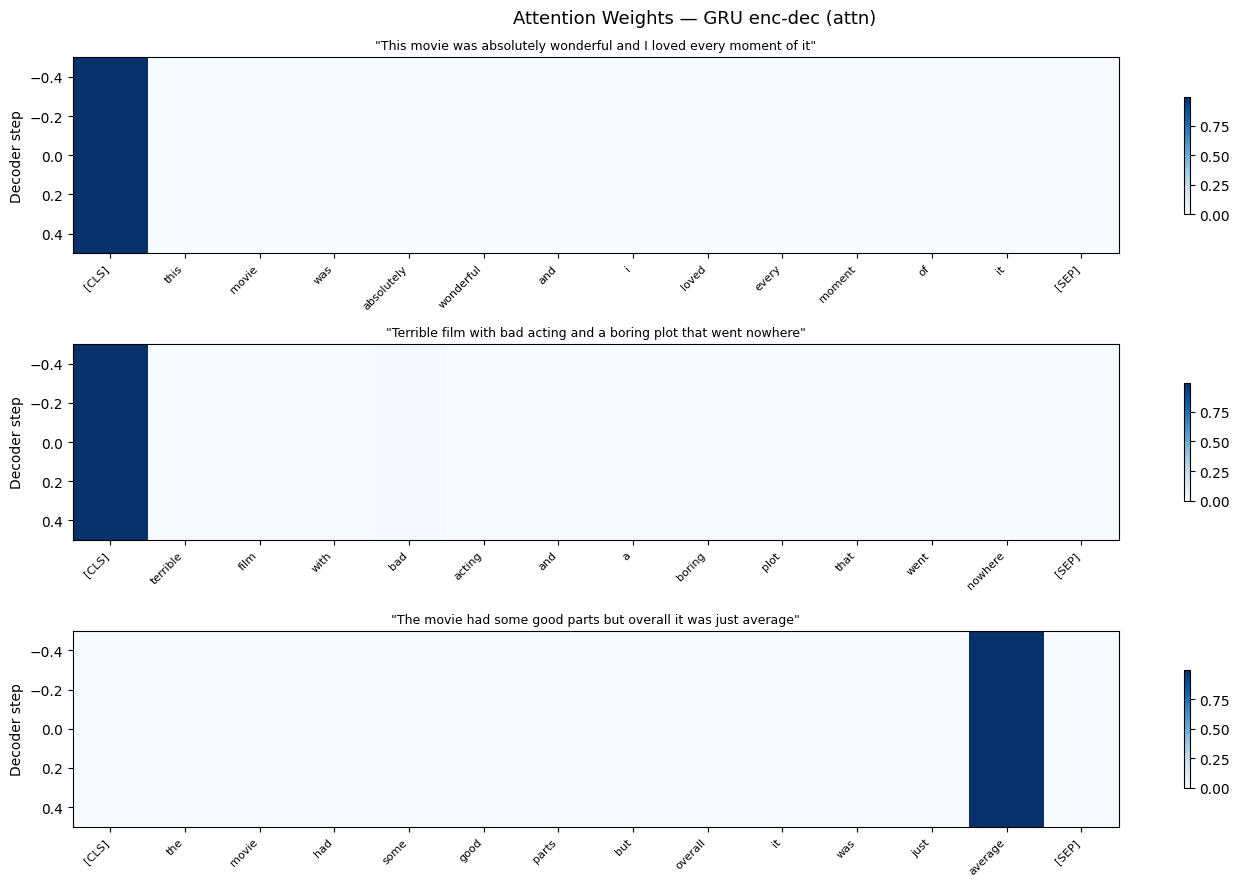

In [16]:
# 4. Attention visualization for GRU enc-dec (attn) — experiment 4
# Uses a forward hook to capture attention weights without modifying source code
import sys
sys.path.insert(0, '.')
from gru_solution import EncoderDecoder, Attn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class _Wrapper(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.back_bone = EncoderDecoder(
            vocabulary_size=30522, dropout=0.3, encoder_only=False, with_attn=True
        )
        self.classifier = torch.nn.Linear(256, 2)

model = _Wrapper()
model.load_state_dict(state_dicts['4'])
model.to(device)
model.eval()

# Hook to capture attention weights
attn_weights_captured = []
def attn_hook(module, input, output):
    # output[1] is attention weights, shape varies by implementation
    attn_weights_captured.append(output[1].detach().cpu())

hook_handle = model.back_bone.decoder.mlp_attn.register_forward_hook(attn_hook)

# Sample sentences to visualize
sample_texts = [
    "This movie was absolutely wonderful and I loved every moment of it",
    "Terrible film with bad acting and a boring plot that went nowhere",
    "The movie had some good parts but overall it was just average",
]

fig, axes = plt.subplots(len(sample_texts), 1, figsize=(14, 3 * len(sample_texts)))

for idx, text in enumerate(sample_texts):
    attn_weights_captured.clear()
    tokens = tokenizer.encode(text, add_special_tokens=True, max_length=256, padding='max_length', truncation=True)
    input_ids = torch.tensor([tokens], device=device)
    mask = (input_ids != 0).long()

    with torch.no_grad():
        _ = model.back_bone(input_ids, mask)

    if attn_weights_captured:
        # Debug: print shape of first captured weight to understand structure
        if idx == 0:
            print(f"Number of captured weights: {len(attn_weights_captured)}")
            print(f"Shape of each: {attn_weights_captured[0].shape}")

        # Stack into (num_steps, seq_len) — flatten each to 1D first
        attn_matrix = torch.stack([w.flatten() for w in attn_weights_captured])  # (num_steps, seq_len)

        token_strs = tokenizer.convert_ids_to_tokens(tokens)
        n_real = mask.cpu().sum().item()

        # Only show non-padding decoder steps and input tokens
        attn_display = attn_matrix[:n_real, :n_real].numpy()
        token_display = token_strs[:n_real]

        ax = axes[idx]
        im = ax.imshow(attn_display, aspect='auto', cmap='Blues')
        ax.set_xticks(range(len(token_display)))
        ax.set_xticklabels(token_display, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Decoder step')
        ax.set_title(f'"{text}"', fontsize=9)
        plt.colorbar(im, ax=ax, shrink=0.6)

hook_handle.remove()
fig.suptitle('Attention Weights — GRU enc-dec (attn)', fontsize=13)
plt.tight_layout()
plt.show()

# That's a significant finding. It means the attention mechanism is largely not doing its job — instead 
# of learning to focus on sentiment-bearing words (like "wonderful" or "terrible"), it's collapsing to 
# just reading the CLS token's encoder representation.

# A few takeaways:
# 1. The attention is redundant — if the decoder mostly attends to CLS, it's effectively just using the 
# encoder's summary vector, which is the same thing the encoder-only model does without attention. This 
# explains why experiment 4 doesn't outperform experiment 1 despite having more parameters and the attention mechanism.
# 2. The mixed-sentiment example breaks the pattern — the third sentence ("good parts but overall just average") 
# has conflicting signals, so the model can't rely on a single summary and is forced to attend to actual content 
# tokens. This suggests the attention could learn useful patterns but defaults to the lazy CLS shortcut when 
# sentiment is clear.
# 3. CLS attention as a failure mode — this is a known issue where attention mechanisms converge to attending to 
# special tokens (CLS, SEP, padding) because they act as "no-op" or default positions. The model finds it easier to 
# route everything through CLS than to learn fine-grained token-level attention.

# This would be a good observation to include in your assignment writeup — it shows the attention mechanism adds 
# parameters and compute cost without meaningfully improving the model's decision-making process.

## System Usage

In [21]:
# show a table of data/system_usage/usage.csv
# render the table in latex format as well
import pandas as pd

usage_df = pd.read_csv('data/system_usage/usage.csv')
usage_df['Experiment'] = usage_df['Experiment'].str.extract(r'(\d+)')
usage_df = usage_df.rename(columns={'Experiment': 'Exp'})
usage_df = usage_df.drop(columns=[c for c in usage_df.columns if 'Total' in c])
display(usage_df.style.hide(axis='index').format(precision=1))

# LaTeX table
latex_lines = []
latex_lines.append(r'\begin{table}[ht]')
latex_lines.append(r'\centering')
latex_lines.append(r'\caption{System resource usage per experiment.}')
latex_lines.append(r'\label{tab:system_usage}')
latex_lines.append(r'\begin{tabular}{lccc}')
latex_lines.append(r'\toprule')
latex_lines.append(r'\textbf{Exp} & \textbf{RAM Used (GB)} & \textbf{GPU Used (GB)} & \textbf{Disk Used (GB)} \\')
latex_lines.append(r'\midrule')

for _, row in usage_df.iterrows():
    line = (
        f"{row['Exp']} & "
        f"{row['System RAM Used (GB)']:.1f} & "
        f"{row['GPU RAM Used (GB)']:.1f} & "
        f"{row['Disk Used (GB)']:.1f} \\\\"
    )
    latex_lines.append(line)

latex_lines.append(r'\bottomrule')
latex_lines.append(r'\end{tabular}')
latex_lines.append(r'\end{table}')

latex_table = '\n'.join(latex_lines)
print(latex_table)

with open(os.path.join(FIGURES_DIR, 'system_usage_table.tex'), 'w') as f:
    f.write(latex_table)
print(f"\nSaved to {FIGURES_DIR}/system_usage_table.tex")

Exp,System RAM Used (GB),GPU RAM Used (GB),Disk Used (GB)
1,3.7,5.5,44.3
2,3.8,5.5,44.3
3,3.9,6.3,44.3
4,3.9,7.1,44.3
5,4.0,7.2,44.3
6,4.0,11.9,44.3
7,3.9,6.7,44.3
8,4.0,7.4,44.7


\begin{table}[ht]
\centering
\caption{System resource usage per experiment.}
\label{tab:system_usage}
\begin{tabular}{lccc}
\toprule
\textbf{Exp} & \textbf{RAM Used (GB)} & \textbf{GPU Used (GB)} & \textbf{Disk Used (GB)} \\
\midrule
1 & 3.7 & 5.5 & 44.3 \\
2 & 3.8 & 5.5 & 44.3 \\
3 & 3.9 & 6.3 & 44.3 \\
4 & 3.9 & 7.1 & 44.3 \\
5 & 4.0 & 7.2 & 44.3 \\
6 & 4.0 & 11.9 & 44.3 \\
7 & 3.9 & 6.7 & 44.3 \\
8 & 4.0 & 7.4 & 44.7 \\
\bottomrule
\end{tabular}
\end{table}

Saved to figures/system_usage_table.tex
